# Ephrat 2017 Faithful Baseline
Separate baseline: K=9 frames + optical flow -> mel, CBHG -> linear spectrogram, Griffin-Lim -> waveform. No landmarks, no SpeechBrain, no HiFi-GAN.


In [16]:
# Optional if missing:
# %pip install librosa opencv-python mediapipe decord torchaudio tqdm


In [1]:
import os, glob, random, time, subprocess
from pathlib import Path
import cv2, librosa, mediapipe as mp, numpy as np, torch, torchaudio
import torch.nn as nn
import torch.nn.functional as F
from decord import VideoReader, cpu
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm


In [2]:
DATASET_ROOT="Dataset_Output"
CACHE_DIR="Ephrat_Baseline_Data"
CKPT_DIR="ephrat_baseline_checkpoints"
FPS=25; SR=16000; K=9; HALF_K=K//2; H=160; W=128
N_MELS=80; N_FFT=640; WIN_LENGTH=640; HOP_LENGTH=160
AUDIO_PER_VIDEO=int(round((SR/FPS)/HOP_LENGTH)) # 4
OUT_AUDIO_FRAMES=4
BATCH_SIZE=16; LR=1e-3; SEED=42; NUM_WORKERS=0
PREPROCESS_LIMIT=5; PREPROCESS_OVERWRITE=False; CONVERT_VIDEO_FPS=True
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print('device', DEVICE, 'audio/video', AUDIO_PER_VIDEO)


device cuda audio/video 4


In [3]:
def safe_name(folder):
    p=Path(folder).parts
    return f"{p[-2]}_{p[-1]}" if len(p)>=2 else Path(folder).name

def utterance_folders(root=DATASET_ROOT):
    out=[]
    for v in sorted(glob.glob(os.path.join(root,'**','video.mp4'), recursive=True)):
        f=os.path.dirname(v)
        if glob.glob(os.path.join(f,'audio.*')): out.append(f)
    return out

def convert_fps(src,dst):
    subprocess.run(['ffmpeg','-hide_banner','-loglevel','error','-y','-i',src,'-r',str(FPS),'-vcodec','libx264','-pix_fmt','yuv420p','-crf','23','-preset','fast',dst], check=True, capture_output=True)

def rm(path):
    if path and os.path.exists(path):
        try: os.remove(path)
        except PermissionError: pass

def detector(model='face_landmarker_v2_with_blendshapes.task'):
    if not os.path.exists(model): raise FileNotFoundError(model)
    base=python.BaseOptions(model_asset_path=model)
    opts=vision.FaceLandmarkerOptions(base_options=base, running_mode=vision.RunningMode.VIDEO, num_faces=1, output_face_blendshapes=False, output_facial_transformation_matrixes=False)
    return vision.FaceLandmarker.create_from_options(opts)

def crop_face(frame, lms):
    h,w=frame.shape[:2]
    pts=np.array([[lm.x*w,lm.y*h] for lm in lms], np.float32)
    x1,y1=pts.min(0); x2,y2=pts.max(0)
    bw,bh=x2-x1,y2-y1; cx,cy=(x1+x2)/2,(y1+y2)/2+0.05*bh
    ratio=W/H; ch=bh*1.25; cw=max(bw*1.20,ch*ratio); ch=max(ch,cw/ratio)
    x1=int(round(cx-cw/2)); x2=int(round(cx+cw/2)); y1=int(round(cy-ch/2)); y2=int(round(cy+ch/2))
    pl,pt,pr,pb=max(0,-x1),max(0,-y1),max(0,x2-w),max(0,y2-h)
    if pl or pt or pr or pb:
        frame=cv2.copyMakeBorder(frame,pt,pb,pl,pr,cv2.BORDER_CONSTANT,value=0); x1+=pl; x2+=pl; y1+=pt; y2+=pt
    crop=frame[y1:y2,x1:x2]
    if crop.size==0: crop=np.zeros((H,W,3),np.uint8)
    else: crop=cv2.resize(crop,(W,H),interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(crop,cv2.COLOR_RGB2GRAY).astype(np.float32)/255.0

def extract_frames(video_path):
    det=detector(); vr=None; frames=[]; last=None
    try:
        vr=VideoReader(video_path, ctx=cpu(0))
        for i in range(len(vr)):
            fr=vr[i].asnumpy(); img=mp.Image(image_format=mp.ImageFormat.SRGB, data=fr)
            res=det.detect_for_video(img, int(i*1000/FPS))
            if res.face_landmarks:
                last=crop_face(fr, res.face_landmarks[0]); frames.append(last)
            else:
                frames.append(last.copy() if last is not None else np.zeros((H,W),np.float32))
    finally:
        det.close()
        if vr is not None: del vr
    if not frames: raise RuntimeError('no frames '+video_path)
    return np.stack(frames).astype(np.float32)

def optical_flow(frames):
    flows=[np.zeros((2,H,W),np.float32)]; prev=(frames[0]*255).astype(np.uint8)
    for i in range(1,len(frames)):
        cur=(frames[i]*255).astype(np.uint8)
        fl=cv2.calcOpticalFlowFarneback(prev,cur,None,0.5,3,15,3,5,1.2,0)
        flows.append(fl.transpose(2,0,1).astype(np.float32)); prev=cur
    return np.stack(flows).astype(np.float32)

def norm_log(mag, eps=1e-5):
    x=np.log(np.maximum(mag,eps)).astype(np.float32); lo=float(x.min()); hi=float(x.max())
    return ((x-lo)/max(hi-lo,1e-8)).astype(np.float32),lo,hi

def audio_feats(path):
    y,_=librosa.load(path,sr=SR,mono=True); y=y.astype(np.float32)
    lin=np.abs(librosa.stft(y,n_fft=N_FFT,hop_length=HOP_LENGTH,win_length=WIN_LENGTH,window='hann',center=True))
    lin,lin_lo,lin_hi=norm_log(lin)
    mel=librosa.feature.melspectrogram(y=y,sr=SR,n_fft=N_FFT,hop_length=HOP_LENGTH,win_length=WIN_LENGTH,n_mels=N_MELS,fmin=0,fmax=SR/2,power=1.0,center=True,norm='slaney',htk=False)
    mel,mel_lo,mel_hi=norm_log(mel)
    return dict(waveform=y, linear=lin.T.astype(np.float32), mel=mel.T.astype(np.float32), linear_log_min=lin_lo, linear_log_max=lin_hi, mel_log_min=mel_lo, mel_log_max=mel_hi)


In [4]:
def preprocess_one(folder, overwrite=False):
    os.makedirs(CACHE_DIR, exist_ok=True); out=os.path.join(CACHE_DIR, safe_name(folder)+'.pt')
    if os.path.exists(out) and not overwrite: return out
    vids=glob.glob(os.path.join(folder,'video.*')); auds=glob.glob(os.path.join(folder,'audio.*'))
    if not vids or not auds: raise FileNotFoundError(folder)
    src=vids[0]; tmp=os.path.join(folder,'temp_ephrat_25fps.mp4'); read=src
    try:
        if CONVERT_VIDEO_FPS: convert_fps(src,tmp); read=tmp
        frames=extract_frames(read); flows=optical_flow(frames); af=audio_feats(auds[0])
        max_audio=min(af['mel'].shape[0], af['linear'].shape[0]); max_video=max_audio//AUDIO_PER_VIDEO
        frames=frames[:max_video]; flows=flows[:max_video]
        data={
            'frames':torch.from_numpy(frames), 'flows':torch.from_numpy(flows),
            'mel':torch.from_numpy(af['mel']), 'linear':torch.from_numpy(af['linear']), 'waveform':torch.from_numpy(af['waveform']),
            'video_len':int(frames.shape[0]), 'audio_feature_len':int(max_audio), 'sample_rate':SR, 'fps':FPS,
            'n_fft':N_FFT, 'win_length':WIN_LENGTH, 'hop_length':HOP_LENGTH, 'n_mels':N_MELS, 'k':K,
            'linear_log_min':af['linear_log_min'], 'linear_log_max':af['linear_log_max'], 'mel_log_min':af['mel_log_min'], 'mel_log_max':af['mel_log_max'],
            'source_folder':folder, 'source_video':src, 'source_audio':auds[0]}
        torch.save(data,out); return out
    finally:
        rm(tmp)

def build_cache(limit=PREPROCESS_LIMIT, overwrite=PREPROCESS_OVERWRITE):
    folders=utterance_folders(); folders=folders if limit is None else folders[:limit]
    print('preprocess',len(folders),'utterances')
    paths=[]
    for f in tqdm(folders):
        try:
            p=preprocess_one(f,overwrite); d=torch.load(p,map_location='cpu',weights_only=False)
            print(os.path.basename(p), tuple(d['frames'].shape), tuple(d['flows'].shape), tuple(d['mel'].shape), tuple(d['linear'].shape)); paths.append(p)
        except Exception as e:
            print('ERROR',f,e); import traceback; traceback.print_exc()
    return paths

# cache_paths=build_cache(limit=5, overwrite=False)


In [5]:
class EphratDataset(Dataset):
    def __init__(self, paths, preload=False):
        self.paths=list(paths); self.preload=preload; self.index=[]; self.cache={}
        for fi,p in enumerate(self.paths):
            d=torch.load(p,map_location='cpu',weights_only=False)
            if preload: self.cache[fi]=d
            T=int(d['video_len']); A=min(d['mel'].shape[0], d['linear'].shape[0])
            for c in range(HALF_K, T-HALF_K):
                a0=c*AUDIO_PER_VIDEO; a1=a0+OUT_AUDIO_FRAMES
                if a1<=A: self.index.append((fi,c))
        if not self.index: raise RuntimeError('no valid windows')
    def __len__(self): return len(self.index)
    def _data(self, fi):
        if fi in self.cache: return self.cache[fi]
        return torch.load(self.paths[fi],map_location='cpu',weights_only=False)
    def __getitem__(self,i):
        fi,c=self.index[i]; d=self._data(fi); p=self.paths[fi]
        s=c-HALF_K; e=c+HALF_K+1; a0=c*AUDIO_PER_VIDEO; a1=a0+OUT_AUDIO_FRAMES
        img=d['frames'][s:e].float()                 # (9,H,W) as channels
        flo=d['flows'][s:e].float().reshape(K*2,H,W) # (18,H,W)
        return img, flo, d['mel'][a0:a1].float(), d['linear'][a0:a1].float(), p, c

def split_paths(cache_dir=CACHE_DIR):
    paths=sorted(glob.glob(os.path.join(cache_dir,'*.pt'))); random.Random(SEED).shuffle(paths)
    if len(paths)<3: raise RuntimeError('need >=3 cache files')
    n=len(paths); nt=max(1,int(n*.8)); nv=max(1,int(n*.1))
    tr=paths[:nt]; va=paths[nt:nt+nv]; te=paths[nt+nv:] or va
    return tr,va,te

def loaders(batch_size=BATCH_SIZE):
    tr,va,te=split_paths(); ds_tr=EphratDataset(tr); ds_va=EphratDataset(va); ds_te=EphratDataset(te)
    print('utterances',len(tr),len(va),len(te),'samples',len(ds_tr),len(ds_va),len(ds_te))
    return (DataLoader(ds_tr,batch_size=batch_size,shuffle=True,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available()),
            DataLoader(ds_va,batch_size=batch_size,shuffle=False,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available()),
            DataLoader(ds_te,batch_size=1,shuffle=False,num_workers=0))
# train_loader,val_loader,test_loader=loaders()


In [6]:
class ResBlock(nn.Module):
    def __init__(self,ci,co,stride=1,drop=.25):
        super().__init__(); self.act=nn.LeakyReLU(.2,True); self.drop=nn.Dropout2d(drop)
        self.c1=nn.Conv2d(ci,co,1,stride,bias=False); self.b1=nn.BatchNorm2d(co)
        self.c2=nn.Conv2d(co,co,3,1,1,bias=False); self.b2=nn.BatchNorm2d(co)
        self.c3=nn.Conv2d(co,co,1,bias=False); self.b3=nn.BatchNorm2d(co)
        self.skip=nn.Identity() if (ci==co and stride==1) else nn.Sequential(nn.Conv2d(ci,co,1,stride,bias=False), nn.BatchNorm2d(co))
    def forward(self,x):
        r=self.skip(x); y=self.act(self.b1(self.c1(x))); y=self.act(self.b2(self.c2(y))); y=self.b3(self.c3(y))
        return self.drop(self.act(y+r))
class Tower(nn.Module):
    def __init__(self,ci):
        super().__init__(); ch=[128,128,128,256,256,256,256,512,512,512,512]; strides={0,3,5,7,9}; layers=[]
        for i,co in enumerate(ch): layers.append(ResBlock(ci,co,2 if i in strides else 1)); ci=co
        self.net=nn.Sequential(*layers); self.pool=nn.AdaptiveAvgPool2d(1)
    def forward(self,x): return self.pool(self.net(x)).flatten(1)
class Encoder(nn.Module):
    def __init__(self): super().__init__(); self.img=Tower(K); self.flow=Tower(K*2)
    def forward(self,img,flow): return torch.cat([self.img(img), self.flow(flow)], -1)
class MelDecoder(nn.Module):
    def __init__(self):
        super().__init__(); self.net=nn.Sequential(nn.Linear(1024,1024),nn.LeakyReLU(.2,True),nn.Dropout(.5),nn.Linear(1024,1024),nn.Tanh(),nn.Dropout(.5),nn.Linear(1024,OUT_AUDIO_FRAMES*N_MELS))
    def forward(self,z): return ((torch.tanh(self.net(z))+1)/2).view(z.size(0),OUT_AUDIO_FRAMES,N_MELS)
class Highway(nn.Module):
    def __init__(self,d): super().__init__(); self.H=nn.Linear(d,d); self.T=nn.Linear(d,d); nn.init.constant_(self.T.bias,-1)
    def forward(self,x): t=torch.sigmoid(self.T(x)); return F.relu(self.H(x))*t+x*(1-t)
class CBHG(nn.Module):
    def __init__(self,in_dim=N_MELS,out_dim=N_FFT//2+1,C=128,Kbank=8):
        super().__init__(); self.bank=nn.ModuleList([nn.Sequential(nn.Conv1d(in_dim,C,k,padding=k//2),nn.BatchNorm1d(C),nn.ReLU(True)) for k in range(1,Kbank+1)])
        self.p1=nn.Sequential(nn.Conv1d(C*Kbank,C,3,padding=1),nn.BatchNorm1d(C),nn.ReLU(True)); self.p2=nn.Sequential(nn.Conv1d(C,in_dim,3,padding=1),nn.BatchNorm1d(in_dim))
        self.hw=nn.ModuleList([Highway(in_dim) for _ in range(4)]); self.gru=nn.GRU(in_dim,128,batch_first=True,bidirectional=True); self.out=nn.Linear(256,out_dim)
    def forward(self,mel):
        x=mel.transpose(1,2); T=x.shape[-1]; ys=[]
        for conv in self.bank:
            y=conv(x); y=y[...,:T] if y.shape[-1]>=T else F.pad(y,(0,T-y.shape[-1])); ys.append(y)
        y=F.max_pool1d(torch.cat(ys,1),2,1,1)[...,:T]; y=(self.p2(self.p1(y))+x).transpose(1,2)
        for h in self.hw: y=h(y)
        y,_=self.gru(y); return torch.sigmoid(self.out(y))
class EphratModel(nn.Module):
    def __init__(self): super().__init__(); self.encoder=Encoder(); self.mel=MelDecoder(); self.post=CBHG()
    def forward(self,img,flow):
        m=self.mel(self.encoder(img,flow)); return m,self.post(m)
def freeze_encoder(model, freeze=True):
    for p in model.encoder.parameters(): p.requires_grad=not freeze


In [7]:
def to_dev(batch):
    img,flow,mel,lin,paths,centers=batch
    return img.to(DEVICE), flow.to(DEVICE), mel.to(DEVICE), lin.to(DEVICE)
def epoch(model, loader, opt=None, stage=2):
    train=opt is not None; model.train(train); tot=ml=ll=0; n=0
    for b in tqdm(loader, leave=False):
        img,flow,mel,lin=to_dev(b)
        if train: opt.zero_grad(set_to_none=True)
        pm,pl=model(img,flow); lm=F.mse_loss(pm,mel); ln=F.mse_loss(pl,lin); loss=lm if stage==1 else lm+ln
        if train: loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),5); opt.step()
        tot+=float(loss.detach().cpu()); ml+=float(lm.detach().cpu()); ll+=float(ln.detach().cpu()); n+=1
    return {'loss':tot/max(n,1),'mel_loss':ml/max(n,1),'linear_loss':ll/max(n,1)}
def save_ckpt(path, model, opt, ep, stage, metrics, hist):
    os.makedirs(os.path.dirname(path),exist_ok=True); torch.save({'model_state_dict':model.state_dict(),'optimizer_state_dict':opt.state_dict() if opt else None,'epoch':ep,'stage':stage,'metrics':metrics,'history':hist}, path)
def train(train_loader,val_loader,stage1=30,stage2=70):
    model=EphratModel().to(DEVICE); hist=[]; best=1e9; bad=0
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for e in range(1,stage1+1):
        tr=epoch(model,train_loader,opt,1); va=epoch(model,val_loader,None,1); hist.append({'stage':1,'epoch':e,'train':tr,'val':va}); print(f'S1 {e:03d} train {tr["loss"]:.5f} val {va["loss"]:.5f}')
    freeze_encoder(model, True); opt=torch.optim.Adam([p for p in model.parameters() if p.requires_grad],lr=LR)
    for e in range(1,stage2+1):
        tr=epoch(model,train_loader,opt,2); va=epoch(model,val_loader,None,2); hist.append({'stage':2,'epoch':e,'train':tr,'val':va}); print(f'S2 {e:03d} train {tr["loss"]:.5f} val {va["loss"]:.5f} mel {va["mel_loss"]:.5f} lin {va["linear_loss"]:.5f}')
        save_ckpt(os.path.join(CKPT_DIR,'last_model.pth'),model,opt,e,2,va,hist)
        if va['loss']<best: best=va['loss']; bad=0; save_ckpt(os.path.join(CKPT_DIR,'best_model.pth'),model,opt,e,2,va,hist); print(' saved best')
        else: bad+=1
        if bad>=12: print('early stop'); break
    return model,hist
# model,hist=train(train_loader,val_loader)


In [8]:
def overfit_two(epochs=300, batch_size=4, print_every=1):
    paths=sorted(glob.glob(os.path.join(CACHE_DIR,'*.pt')))[:2]
    if len(paths)<2: raise RuntimeError('build at least 2 cache files first')
    ds=EphratDataset(paths, preload=True)
    loader=DataLoader(ds,batch_size=batch_size,shuffle=True,num_workers=0,pin_memory=torch.cuda.is_available())
    print('overfit files:', [os.path.basename(p) for p in paths])
    print('overfit samples:', len(ds), '| batches/epoch:', len(loader), '| batch_size:', batch_size)
    model=EphratModel().to(DEVICE); opt=torch.optim.Adam(model.parameters(),lr=LR); hist=[]
    for e in range(1,epochs+1):
        t0=time.time()
        m=epoch(model,loader,opt,2); hist.append(m['loss'])
        if e==1 or e%print_every==0 or e==epochs:
            print(f'overfit {e:03d}/{epochs} loss {m["loss"]:.6f} mel {m["mel_loss"]:.6f} lin {m["linear_loss"]:.6f} time {time.time()-t0:.1f}s')
    save_ckpt(os.path.join(CKPT_DIR,'overfit_2utt.pth'),model,opt,epochs,2,m,hist); return model,hist
# overfit_model,overfit_hist=overfit_two(300, print_every=1)


In [9]:
def denorm(norm,lo,hi): return np.maximum(np.exp(norm*(hi-lo)+lo),1e-8).astype(np.float32)
def gweights(n,sigma=.9):
    x=np.arange(n,dtype=np.float32); c=(n-1)/2; w=np.exp(-.5*((x-c)/sigma)**2); return (w/w.max()).reshape(-1,1)
def load_model(path=os.path.join(CKPT_DIR,'best_model.pth')):
    m=EphratModel().to(DEVICE); ck=torch.load(path,map_location=DEVICE,weights_only=False); m.load_state_dict(ck['model_state_dict']); m.eval(); print('loaded',path,ck.get('metrics')); return m
def predict_linear(model, cache_path):
    d=torch.load(cache_path,map_location='cpu',weights_only=False); T=d['linear'].shape[0]; D=d['linear'].shape[1]; acc=np.zeros((T,D),np.float32); wt=np.zeros((T,1),np.float32); w=gweights(OUT_AUDIO_FRAMES)
    with torch.no_grad():
        for c in tqdm(range(HALF_K,int(d['video_len'])-HALF_K)):
            a0=c*AUDIO_PER_VIDEO; a1=a0+OUT_AUDIO_FRAMES
            if a1>T: continue
            s=c-HALF_K; e=c+HALF_K+1
            img=d['frames'][s:e].float().unsqueeze(0).to(DEVICE); flo=d['flows'][s:e].float().reshape(1,K*2,H,W).to(DEVICE)
            _,pl=model(img,flo); acc[a0:a1]+=pl[0].cpu().numpy()*w; wt[a0:a1]+=w
    pred=acc/np.maximum(wt,1e-8); miss=wt[:,0]==0
    if miss.any(): pred[miss]=d['linear'].numpy()[miss]
    return d, denorm(pred,float(d['linear_log_min']),float(d['linear_log_max'])), denorm(d['linear'].numpy(),float(d['linear_log_min']),float(d['linear_log_max']))
def griffin(mag_tf):
    return librosa.griffinlim(mag_tf.T,n_iter=64,hop_length=HOP_LENGTH,win_length=WIN_LENGTH,n_fft=N_FFT,window='hann',center=True,momentum=.99,random_state=SEED).astype(np.float32)
def reconstruct_one(cache_path=None, ckpt=os.path.join(CKPT_DIR,'best_model.pth')):
    if cache_path is None: cache_path=sorted(glob.glob(os.path.join(CACHE_DIR,'*.pt')))[0]
    m=load_model(ckpt); d,pred,gt=predict_linear(m,cache_path); os.makedirs('ephrat_baseline_outputs',exist_ok=True)
    pw=griffin(pred); gw=griffin(gt)
    torchaudio.save('ephrat_baseline_outputs/ephrat_pred.wav',torch.from_numpy(pw).unsqueeze(0),SR)
    torchaudio.save('ephrat_baseline_outputs/ephrat_gt_griffinlim.wav',torch.from_numpy(gw).unsqueeze(0),SR)
    torchaudio.save('ephrat_baseline_outputs/ephrat_gt_original.wav',d['waveform'].float().reshape(1,-1),SR)
    print('saved outputs')



In [ ]:
# PREPROCESS_LIMIT = None
# cache_paths = build_cache(limit=None, overwrite=False)

train_loader, val_loader, test_loader = loaders()
model, hist = train(train_loader, val_loader)

In [10]:
# ===== TRAIN ~300 WINDOWS, HOLD OUT 1 FILE, SAVE PTH =====
import os
import glob
import math
import random
import torch
import torch.nn.functional as F
from torch.utils.data import Subset, DataLoader

TRAIN_WINDOWS = 300
TEST_FILE_INDEX = 0
QUICK_CKPT = os.path.join(CKPT_DIR, "train300_holdout1.pth")

paths = sorted(glob.glob(os.path.join(CACHE_DIR, "*.pt")))
print("cache files:", len(paths))

if len(paths) < 2:
    raise RuntimeError("Cần ít nhất 2 file .pt: 1 file train và 1 file test.")

test_path = paths[TEST_FILE_INDEX]
train_paths = [p for i, p in enumerate(paths) if i != TEST_FILE_INDEX]

print("test file:", os.path.basename(test_path))
print("train files:", len(train_paths))

train_ds_full = EphratDataset(train_paths, preload=True)
test_ds = EphratDataset([test_path], preload=True)

n_train = min(TRAIN_WINDOWS, len(train_ds_full))
indices = list(range(len(train_ds_full)))
random.seed(SEED)
random.shuffle(indices)
indices = indices[:n_train]

train_ds = Subset(train_ds_full, indices)

train_loader = DataLoader(
    train_ds,
    batch_size=min(BATCH_SIZE, n_train),
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=min(BATCH_SIZE, len(test_ds)),
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("actual train windows:", len(train_ds))
print("test windows:", len(test_ds))
print("steps per epoch:", len(train_loader))

model = EphratModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def move_batch(batch):
    # Dataset trả tuple:
    # image_clip, flow_clip, mel_gt, linear_gt, path, center
    img = batch[0].to(DEVICE).float()
    flow = batch[1].to(DEVICE).float()
    mel = batch[2].to(DEVICE).float()
    linear = batch[3].to(DEVICE).float()
    return img, flow, mel, linear


def run_loader(loader, train=False):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_mel = 0.0
    total_lin = 0.0
    total_n = 0

    for batch in loader:
        img, flow, mel, linear = move_batch(batch)

        with torch.set_grad_enabled(train):
            mel_pred, linear_pred = model(img, flow)

            mel_loss = F.mse_loss(mel_pred, mel)
            lin_loss = F.mse_loss(linear_pred, linear)
            loss = mel_loss + lin_loss

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        bs = img.size(0)
        total_loss += loss.detach().item() * bs
        total_mel += mel_loss.detach().item() * bs
        total_lin += lin_loss.detach().item() * bs
        total_n += bs

    return total_loss / total_n, total_mel / total_n, total_lin / total_n


print("Training 1 epoch on ~300 windows...")
train_loss, train_mel, train_lin = run_loader(train_loader, train=True)

print("Evaluating on held-out file...")
test_loss, test_mel, test_lin = run_loader(test_loader, train=False)

print(f"train | loss {train_loss:.6f} | mel {train_mel:.6f} | lin {train_lin:.6f}")
print(f"test  | loss {test_loss:.6f} | mel {test_mel:.6f} | lin {test_lin:.6f}")

torch.save(
    {
        "model": model.state_dict(),
        "model_state_dict": model.state_dict(),  # để load_model() đọc được
        "epoch": 1,
        "train_loss": train_loss,
        "test_loss": test_loss,
        "test_path": test_path,
        "train_windows": len(train_ds),
        "metrics": {
            "train_loss": train_loss,
            "test_loss": test_loss,
            "train_mel": train_mel,
            "train_lin": train_lin,
            "test_mel": test_mel,
            "test_lin": test_lin,
        },
        "config": {
            "FPS": FPS,
            "SR": SR,
            "K": K,
            "H": H,
            "W": W,
            "N_MELS": N_MELS,
            "N_FFT": N_FFT,
            "WIN_LENGTH": WIN_LENGTH,
            "HOP_LENGTH": HOP_LENGTH,
            "OUT_AUDIO_FRAMES": OUT_AUDIO_FRAMES,
        },
    },
    QUICK_CKPT,
)

print("saved:", QUICK_CKPT)


cache files: 342
test file: Mưa đá, giông lốc gây thiệt hại tại nhiều địa phương _ VTV24_00002.pt
train files: 341
actual train windows: 300
test windows: 21
steps per epoch: 19
Training 1 epoch on ~300 windows...
Evaluating on held-out file...
train | loss 0.039426 | mel 0.026013 | lin 0.013413
test  | loss 0.025951 | mel 0.014411 | lin 0.011540
saved: ephrat_baseline_checkpoints\train300_holdout1.pth


In [11]:
reconstruct_one(cache_path=test_path, ckpt=QUICK_CKPT)

loaded ephrat_baseline_checkpoints\train300_holdout1.pth {'train_loss': 0.03942585095763206, 'test_loss': 0.025951176349605833, 'train_mel': 0.02601299397647381, 'train_lin': 0.013412857316434384, 'test_mel': 0.014410932681390218, 'test_lin': 0.011540243889959086}


  0%|          | 0/21 [00:00<?, ?it/s]

saved outputs


Using model
Cache file: Mưa đá, giông lốc gây thiệt hại tại nhiều địa phương _ VTV24_00002.pt
center video frame: 4
mel_pred shape: (4, 80)
mel_gt shape: (4, 80)
mel_pred min/max/mean: 0.29737252 0.68255955 0.48723206
mel_gt   min/max/mean: 0.30212063 0.97407514 0.54519427
mel MSE: 0.009184
mel L1:  0.071235


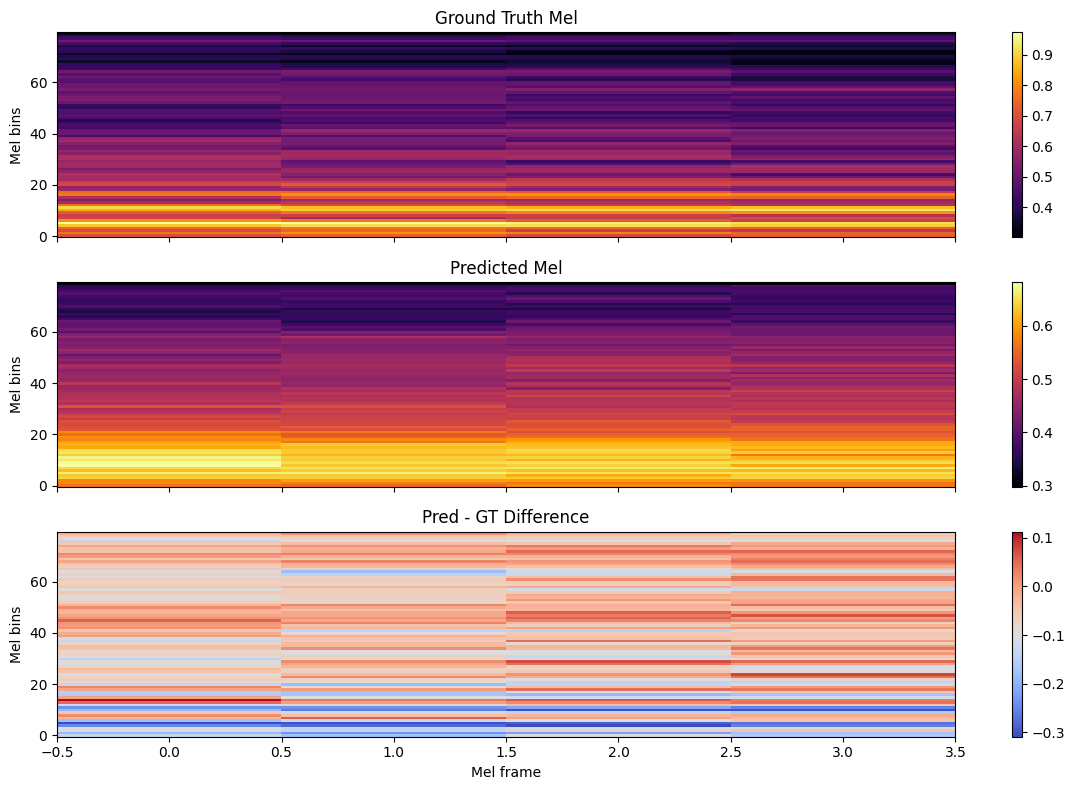

In [12]:
# ===== PLOT PREDICTED MEL VS GROUND-TRUTH MEL =====
import os
import glob
import torch
import matplotlib.pyplot as plt

# Chọn model để xem mel
# Ưu tiên overfit_model nếu vừa train overfit, nếu không thì load checkpoint best_model.pth
if "overfit_model" in globals():
    eval_model = overfit_model
    print("Using overfit_model")
elif "model" in globals():
    eval_model = model
    print("Using model")
else:
    ckpt_path = os.path.join(CKPT_DIR, "ephrat_baseline_checkpoints\train300_holdout1.pth")
    eval_model = load_model(ckpt_path)
    print(f"Loaded model from {ckpt_path}")

eval_model.eval()

# Chọn 1 file cache để xem
cache_paths = sorted(glob.glob(os.path.join(CACHE_DIR, "*.pt")))
if len(cache_paths) == 0:
    raise RuntimeError("No cache files found. Run build_cache(...) first.")

cache_path = cache_paths[0]
print("Cache file:", os.path.basename(cache_path))

# Lấy 1 sample đầu tiên từ file này
sample_ds = EphratDataset([cache_path], preload=True)
sample = sample_ds[0]

image_clip, flow_clip, mel_gt, linear_gt, path, center = sample

image_clip = image_clip.unsqueeze(0).to(DEVICE)  # (1, 9, 160, 128)
flow_clip = flow_clip.unsqueeze(0).to(DEVICE)    # (1, 18, 160, 128)

with torch.no_grad():
    mel_pred, linear_pred = eval_model(image_clip, flow_clip)

mel_pred_np = mel_pred[0].detach().cpu().numpy()  # (4, 80)
mel_gt_np = mel_gt.detach().cpu().numpy()         # (4, 80)

print("center video frame:", center)
print("mel_pred shape:", mel_pred_np.shape)
print("mel_gt shape:", mel_gt_np.shape)
print(
    "mel_pred min/max/mean:",
    mel_pred_np.min(),
    mel_pred_np.max(),
    mel_pred_np.mean(),
)
print(
    "mel_gt   min/max/mean:",
    mel_gt_np.min(),
    mel_gt_np.max(),
    mel_gt_np.mean(),
)

mel_mse = ((mel_pred_np - mel_gt_np) ** 2).mean()
mel_l1 = abs(mel_pred_np - mel_gt_np).mean()
print(f"mel MSE: {mel_mse:.6f}")
print(f"mel L1:  {mel_l1:.6f}")

# Plot mel
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

im0 = axes[0].imshow(
    mel_gt_np.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="inferno",
)
axes[0].set_title("Ground Truth Mel")
axes[0].set_ylabel("Mel bins")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(
    mel_pred_np.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="inferno",
)
axes[1].set_title("Predicted Mel")
axes[1].set_ylabel("Mel bins")
plt.colorbar(im1, ax=axes[1])

diff = mel_pred_np - mel_gt_np
im2 = axes[2].imshow(
    diff.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="coolwarm",
)
axes[2].set_title("Pred - GT Difference")
axes[2].set_xlabel("Mel frame")
axes[2].set_ylabel("Mel bins")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

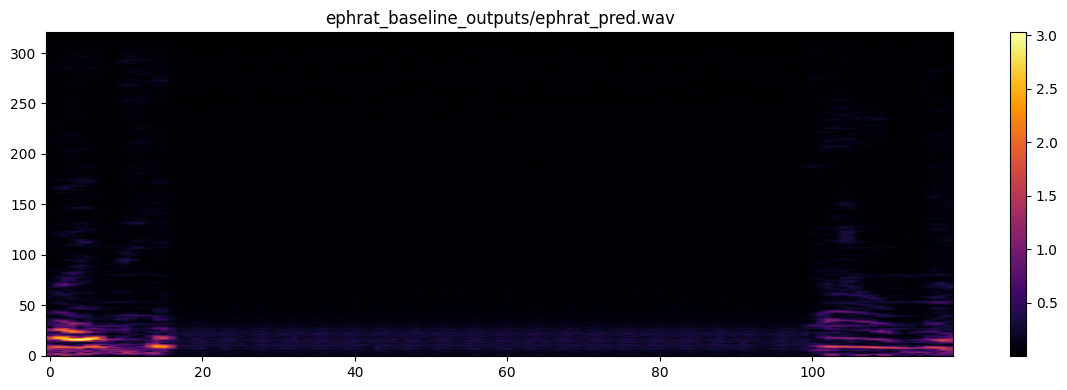

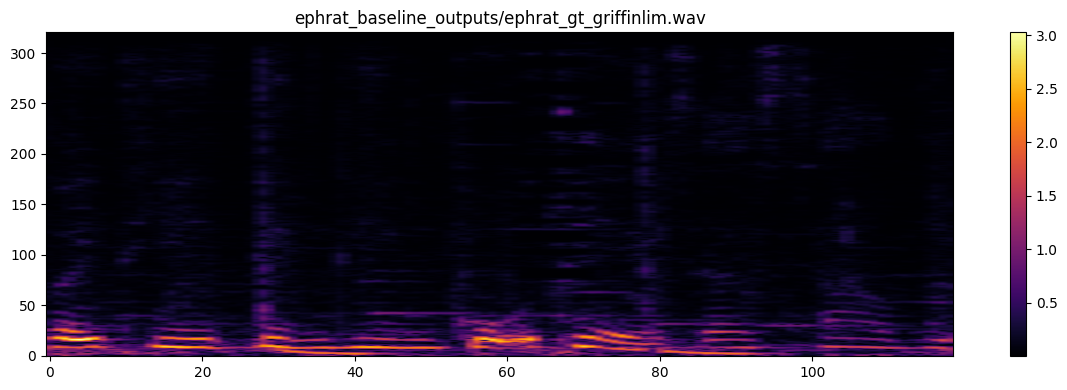

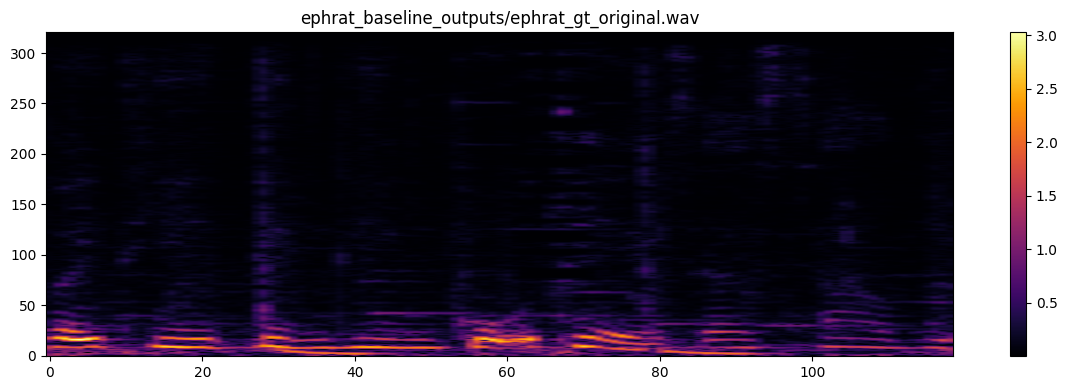

In [12]:
import matplotlib.pyplot as plt
import librosa
import numpy as np

def plot_wav_spec(path):
    y, sr = librosa.load(path, sr=16000)
    S = np.log1p(np.abs(librosa.stft(y, n_fft=640, hop_length=160, win_length=640)))
    plt.figure(figsize=(12, 4))
    plt.imshow(S, aspect="auto", origin="lower", cmap="inferno")
    plt.title(path)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

plot_wav_spec("ephrat_baseline_outputs/ephrat_pred.wav")
plot_wav_spec("ephrat_baseline_outputs/ephrat_gt_griffinlim.wav")
plot_wav_spec("ephrat_baseline_outputs/ephrat_gt_original.wav")